# Ensemble

Autor: Bartosz Perz

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

In [1]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings("ignore")

obesity = fetch_ucirepo(id=544)
X = obesity.data.features
y = obesity.data.targets

print(X.info())
print(X.head())
print(y.value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

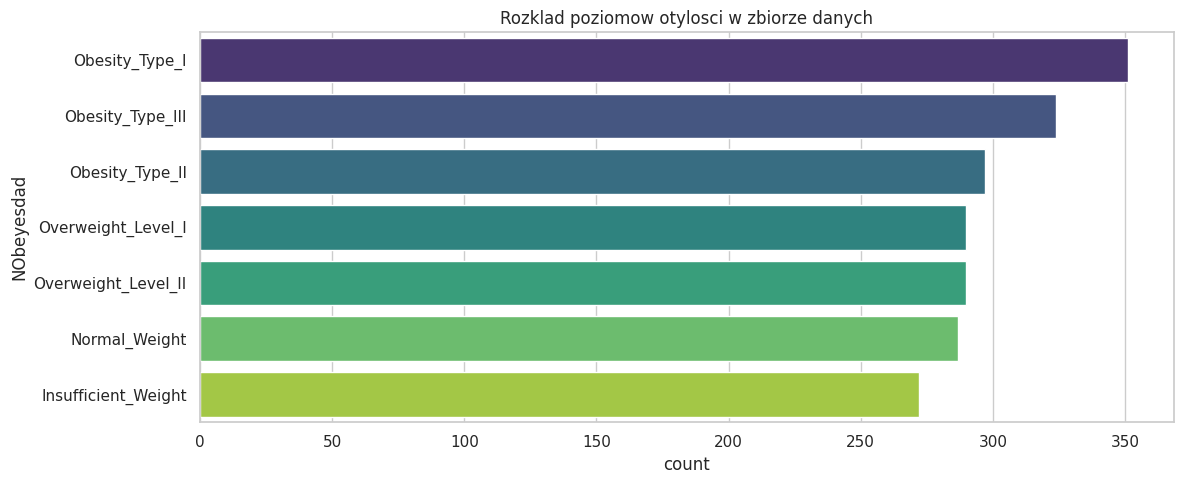

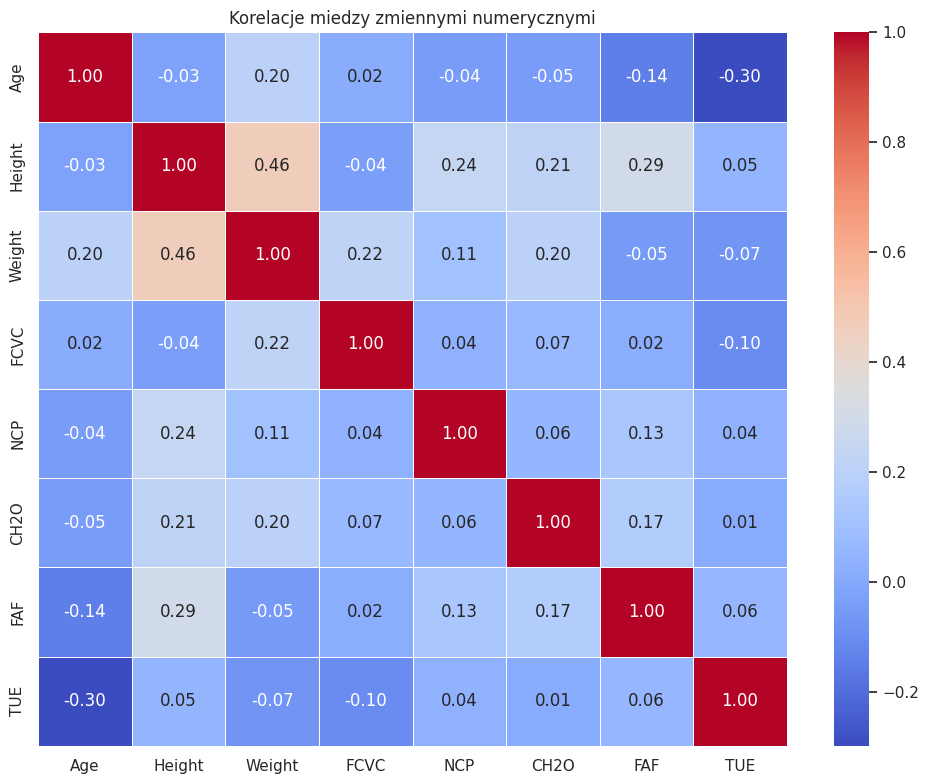

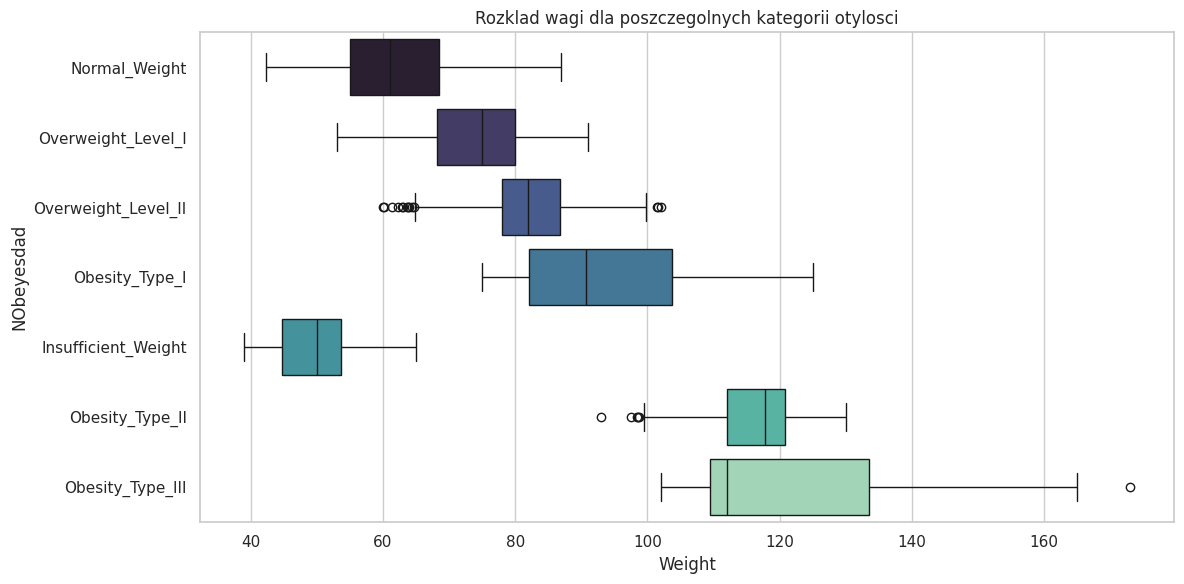

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

plt.figure(figsize=(12, 5))
sns.countplot(data=y, y="NObeyesdad", order=y["NObeyesdad"].value_counts().index, palette="viridis")
plt.title("Rozklad poziomow otylosci w zbiorze danych")
plt.tight_layout()
plt.show()

numerical_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
plt.figure(figsize=(10, 8))
sns.heatmap(X[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korelacje miedzy zmiennymi numerycznymi")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="Weight", y="NObeyesdad", data=pd.concat([X, y], axis=1), palette="mako")
plt.title("Rozklad wagi dla poszczegolnych kategorii otylosci")
plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y.squeeze(), test_size=0.3, random_state=42, stratify=y)

X_train = X_train.copy()
X_test = X_test.copy()

num_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(X_train.shape)
print(X_test.shape)

(1477, 23)
(634, 23)


**Drzewo Decyzyjne**

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)
dt_probs = dt_model.predict_proba(X_test)
dt_conf = np.mean(np.max(dt_probs, axis=1))

print(f"Accuracy: {dt_acc * 100:.2f}%")
print(f"Confidence: {dt_conf * 100:.2f}%")

Accuracy: 91.96%
Confidence: 100.00%


In [6]:
%timeit dt_model.predict(X_test)

904 μs ± 33.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


**Regresja**

In [7]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
lr_probs = lr_model.predict_proba(X_test)
lr_conf = np.mean(np.max(lr_probs, axis=1))

print(f"Accuracy: {lr_acc * 100:.2f}%")
print(f"Confidence: {lr_conf * 100:.2f}%")

Accuracy: 87.07%
Confidence: 74.11%


In [8]:
%timeit lr_model.predict(X_test)

709 μs ± 46.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


**Modele Zespołowe** Bagging

In [9]:
from sklearn.ensemble import BaggingClassifier

ests = {
    "S": DecisionTreeClassifier(max_depth=3, random_state=42),
    "D": DecisionTreeClassifier(random_state=42),
    "L": LogisticRegression(max_iter=1000, random_state=42)
}
configs = [
    ("S", 10, 1, 0), ("S", 50, 1, 0),
    ("D", 10, 1, 0), ("D", 50, 1, 0), ("D", 50, 0, 0), ("D", 50, 1, 1),
    ("L", 10, 1, 0), ("L", 50, 1, 0)
]
results = []
for k, n, b, bf in configs:
    m = BaggingClassifier(estimator=ests[k], n_estimators=n, bootstrap=bool(b), bootstrap_features=bool(bf), random_state=42, n_jobs=-1).fit(X_train, y_train)
    results.append([k, n, b, bf, f"{accuracy_score(y_test, m.predict(X_test))*100:.2f}%", f"{np.mean(np.max(m.predict_proba(X_test), 1))*100:.2f}%"])

print(pd.DataFrame(results, columns=["Est", "n_est", "boot", "boot_feat", "Acc", "Conf"]).to_string(index=False))

Est  n_est  boot  boot_feat    Acc   Conf
  S     10     1          0 69.24% 61.95%
  S     50     1          0 69.56% 61.79%
  D     10     1          0 93.38% 92.46%
  D     50     1          0 95.11% 92.10%
  D     50     0          0 91.48% 98.04%
  D     50     1          1 95.43% 81.56%
  L     10     1          0 85.80% 73.83%
  L     50     1          0 85.96% 73.81%


Boosting

In [11]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

ests = {
    "AT": DecisionTreeClassifier(max_depth=3, random_state=42),
    "AL": LogisticRegression(max_iter=1000, random_state=42)
}
configs = [
    ("Ada_Tree", AdaBoostClassifier(estimator=ests["AT"], n_estimators=50, learning_rate=0.1, random_state=42)),
    ("Ada_Tree", AdaBoostClassifier(estimator=ests["AT"], n_estimators=50, learning_rate=1.0, random_state=42)),
    ("Ada_Tree", AdaBoostClassifier(estimator=ests["AT"], n_estimators=100, learning_rate=0.1, random_state=42)),
    ("Ada_LR", AdaBoostClassifier(estimator=ests["AL"], n_estimators=50, learning_rate=0.1, random_state=42)),
    ("Ada_LR", AdaBoostClassifier(estimator=ests["AL"], n_estimators=50, learning_rate=1.0, random_state=42)),
    ("GradBoost", GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42)),
    ("GradBoost", GradientBoostingClassifier(n_estimators=50, learning_rate=1.0, random_state=42)),
    ("GradBoost", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
]
results = []
for name, m in configs:
    m.fit(X_train, y_train)
    results.append([name, m.n_estimators, m.learning_rate, f"{accuracy_score(y_test, m.predict(X_test))*100:.2f}%", f"{np.mean(np.max(m.predict_proba(X_test), axis=1))*100:.2f}%"])

print(pd.DataFrame(results, columns=["Model", "n_est", "lr", "Acc", "Conf"]).to_string(index=False))

    Model  n_est  lr    Acc   Conf
 Ada_Tree     50 0.1 87.38% 15.47%
 Ada_Tree     50 1.0 89.27% 15.09%
 Ada_Tree    100 0.1 90.85% 15.35%
   Ada_LR     50 0.1 62.15% 15.53%
   Ada_LR     50 1.0 46.37% 14.73%
GradBoost     50 0.1 92.90% 88.00%
GradBoost     50 1.0 95.27% 98.86%
GradBoost    100 0.1 95.27% 94.31%


In [12]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

base_models = [
    ("gb", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
    ("bag", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=50, bootstrap=True, bootstrap_features=True, random_state=42, n_jobs=-1)),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
]

voting = VotingClassifier(estimators=base_models, voting="soft")
voting.fit(X_train, y_train)

stacking = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(), n_jobs=-1)
stacking.fit(X_train, y_train)

for name, model in [("Voting", voting), ("Stacking", stacking)]:
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    probs = model.predict_proba(X_test)
    conf = np.mean(np.max(probs, axis=1))
    print(f"{name} Accuracy: {acc*100:.2f}% | Confidence: {conf*100:.2f}%")

Voting Accuracy: 94.79% | Confidence: 82.00%
Stacking Accuracy: 96.06% | Confidence: 95.14%


1. Który model wdrażamy? zależy gdzie. W dużych miastach i szpitalach, gdzie mają porządny sprzęt, najlepiej dać Gradient Boosting albo Stacking. Wyciągają one 95-96% celności, więc rzadko się pomylą. Ale w wiejskich przychodniach lepiej dać zwykłe drzewo decyzyjne albo regersję logistyczną. Są mega szybkie (< 1 ms na predykcję) i pójdą na każdym kalkulatorze, a celność 87-92% to wciąż super wynik

2. Czy sama dokładność to wszystko? Nie. Po pierwsze liczy się interpretowalnosć. Drzewo decyzyjne da się łatwo narysować i wytłumaczyć pacjentowi, a Stacking to czarna skrzynka. Po drugie, czas i wymagania sprzętowe. Nie ma sensu kupować drogich serwerów dla 1% większej celności.

3. Co byłoby stratą kasy? AdaBoost na regresji logistycznej. Ten model kompletnie poległ (celność ok.. 46-62%). Kupowanie drogiego sprzętu tylko po to, żeby odpalić ciężki Stacking w małych przychodniach, to też marnowanie kasy publicznej.

## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="img.jpg" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.

In [13]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings("ignore")

mushrooms = fetch_ucirepo(id=73)
X = mushrooms.data.features
y = mushrooms.data.targets

print(X.info())
print(y.value_counts())
print(X.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   cap-shape                 8124 non-null   str  
 1   cap-surface               8124 non-null   str  
 2   cap-color                 8124 non-null   str  
 3   bruises                   8124 non-null   str  
 4   odor                      8124 non-null   str  
 5   gill-attachment           8124 non-null   str  
 6   gill-spacing              8124 non-null   str  
 7   gill-size                 8124 non-null   str  
 8   gill-color                8124 non-null   str  
 9   stalk-shape               8124 non-null   str  
 10  stalk-root                5644 non-null   str  
 11  stalk-surface-above-ring  8124 non-null   str  
 12  stalk-surface-below-ring  8124 non-null   str  
 13  stalk-color-above-ring    8124 non-null   str  
 14  stalk-color-below-ring    8124 non-null   str  
 15

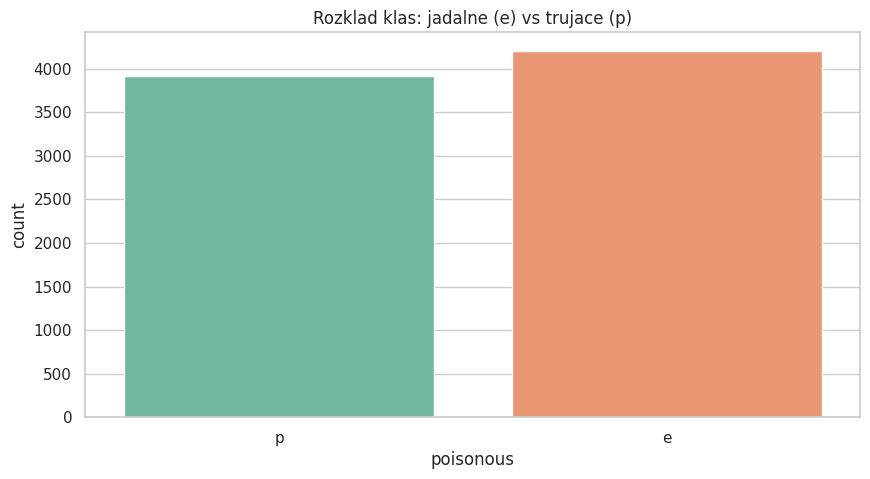

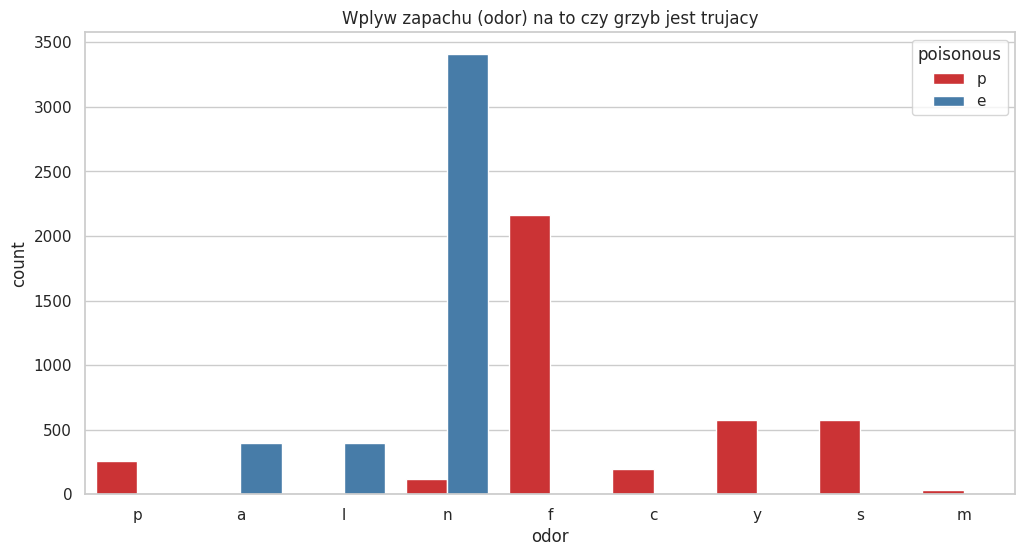

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

plt.figure(figsize=(10, 5))
sns.countplot(data=y, x="poisonous", palette="Set2")
plt.title("Rozklad klas: jadalne (e) vs trujace (p)")
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=pd.concat([X, y], axis=1), x="odor", hue="poisonous", palette="Set1")
plt.title("Wplyw zapachu (odor) na to czy grzyb jest trujacy")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

X = X.fillna("missing")
X_encoded = pd.get_dummies(X, drop_first=True)
y_binary = (y.squeeze() == "p").astype(int)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_binary, test_size=0.3, random_state=42, stratify=y_binary)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

for name, preds, model in [("Decision Tree", y_pred_dt, dt), ("Random Forest", y_pred_rf, rf)]:
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    print(f"{name} - Acc: {acc*100:.2f}% | Recall (Poisonous): {rec*100:.2f}%")
    print(f"Confusion Matrix:\n{cm}\n")

Decision Tree - Acc: 98.48% | Recall (Poisonous): 99.66%
Confusion Matrix:
[[1230   33]
 [   4 1171]]

Random Forest - Acc: 100.00% | Recall (Poisonous): 100.00%
Confusion Matrix:
[[1263    0]
 [   0 1175]]



1. Jaki model wybieramy do lasu? Random Forest. Ma 100% dokładności i czułości, a przy grzybach każda pomyłka to zatrucie lub śmierć.

2. Bezpieczeństwo i interpretacja. Mimo że Random Forest jest bezpieczniejszy, pojedyncze drzewo decyzyjne daje nam super prostą instrukcję "na oko":
    Jeśli grzyb pachnie np. rybą, ostro, stęchlizną: na 100% jest trujący.
    Jeśli nie: musimy uważać na zielony wysyp zarodników i łuskowaty trzon poniżej pierścienia.

3. Oszczędzanie baterii w lesie: Mamy 50 drzew zamiast domyślnych 100, a telefon policzy to w ułamku sekundy. Jak totalnie padnie to możemy korzystać z gotowych instrukcji z drzewa decyzyjnego.